# Applied Machine Learning Assignment 3


Assignment based on the choices13k Dataset ([link](https://github.com/jcpeterson/choices13k)) which contains human decision rates on 13,006 risky choice problems.

As per my assignment I have :
* Used both `c13k_selections.csv` and `c13_problems.json`

* Extracted and engineered features from them

* Used  different ml methods:
    * Linear Regression
    * Ensemble Methods
    * Stacked Ensembles
* And a Neural Network Model (TensorFlow)

* Performed appropriate hyperparameter tuning for each one

* documented best perfoming models which features are important for the prediction, and how.

* Did appropriate train-test splitting and cross-validation as
  appropriate.

* Reported the following metrics for each approach:

  * MAE (primary)
  * $R^2$ 
  * RMSE



I also made a [GitHub Repository](https://github.com/GeorgeKarandreas/applied-machine-learning-assignment-3) for this assignment

GitHub Repo contains:

* A Copy of this Notebook
* The `requirements.txt` that has all dependecies required for this notebook to run
* Both `.csv` and `.json` files used (in folder `/data`)
* NoteBook off all models i attempted ()

## Set up

Imports

In [1]:
import pandas as pd
import numpy as np
import json
import requests
from datetime import datetime
import optuna
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge, ElasticNet, LinearRegression, Lasso
from sklearn.ensemble import StackingRegressor, VotingRegressor
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
import matplotlib.pyplot as plt
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_param_importances

C:\Users\George\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw data files github url (Για να εχω self sustained Notebook)

In [2]:
json_url = 'https://raw.githubusercontent.com/GeorgeKarandreas/applied-machine-learning-assignment-3/refs/heads/main/data/c13k_problems.json'
csv_url = 'https://raw.githubusercontent.com/GeorgeKarandreas/applied-machine-learning-assignment-3/refs/heads/main/data/c13k_selections.csv'

Load Data

In [3]:
df = pd.read_csv(csv_url)

In [4]:
response = requests.get(json_url)
response.raise_for_status()  # raises an error if the request failed

problems = response.json()  # directly parse JSON

if any error is raised and you have `c13k_problems.json` locally un-commennt the block below and load it from here

In [5]:
#with open("c13k_problems.json") as f:
    #problems = json.load(f)

## Feature Engineering

From `c13k_selections.csv`i removed:

* `bRate` because its the target (obviously)

* `Problem` Cause it acts as an index and has no value or correlation to target

* `bRate_std` cause it is derived from `brate` so its considered leakage

All other features were kept since they tell very important fundemental facts about the nature of a problem situation. Example whether or not there was Feedback.
The exact information of each one is on the choice13k repo



From `c13k_problems.json`: 

* From both the payouts and the probabilities I calculated some feature based on intuition (e.g. We can intuitively infer that things like the difference in Expected values `EV_Diff` plays a huge role OR a we can intuitively tell that whether or not the result is a loss or just a smaller reward plays a huge factor on the human decision making ability)

* And some statictical features that play a big role in evaluating the risk of a problem

Specifically:

**Gamble Specific Features (A and B):**

- EV_A / EV_B (Expected Value): Captures the average outcome of the gamble; central to rational choice models.

- Var_A / Var_B (Variance): Measures spread of outcomes; higher variance indicates higher risk.

- SD_A / SD_B (Standard Deviation): Direct measure of volatility, closely related to variance but on the same scale as outcomes.

- Skew_A / Skew_B: Quantifies asymmetry; important if people over- or under-weight unlikely extreme outcomes.

- Max_A / Max_B: The best possible outcome; can influence risk-seeking behavior.

- Min_A / Min_B: The worst possible outcome; relates to loss aversion.

- Range_A / Range_B: Difference between max and min; captures overall spread.

- Prob_max_A / Prob_max_B: Probability of achieving the maximum outcome; informs likelihood of big gains.

- Has_loss_A / Has_loss_B: Binary indicator of whether a gamble has any losses; relevant for loss-averse decision-making.

- CV_A / CV_B (Coefficient of Variation): Standardized risk measure (SD relative to mean), useful when comparing gambles with different scales.



**Loss Based Features**: There is big differnce between how someone view winning vs winning less and winning vs lossing

- Num_losses_A / Num_losses_B: Number of negative outcomes; more losses may deter choice.

- Expected_loss_A / Expected_loss_B: Weighted average of losses; captures typical downside.

- Prob_loss_A / Prob_loss_B: Probability of any loss occurring; reflects likelihood of negative outcomes.

- Max_loss_A / Max_loss_B: Largest loss; highlights extreme negative outcomes.

- Loss_gain_ratio_A / Loss_gain_ratio_B: Expected loss relative to expected gain; indicates relative riskiness.

- Semi_var_A / Semi_var_B (Semi-variance): Variance of losses only; isolates downside risk, ignoring gains.

- EV_diff, Var_diff, Skew_diff, Max_diff, Min_diff, Range_diff, Prob_max_diff, Has_loss_diff: Capture relative differences between gamble B and A; people often compare options rather than evaluating them in isolation.

- Num_losses_diff, Expected_loss_diff, Prob_loss_diff, Max_loss_diff, Loss_gain_ratio_diff, Semi_var_diff: Relative loss-related measures; highlight which gamble is safer or riskier in comparison.

- EV_x_Amb, Skew_x_feedback: Interaction terms allow the effect of differences to depend on context (e.g., ambiguity, feedback), capturing conditional effects on decision-making.


**Excluded Features**

- SD_A / SD_B, CV_A / CV_B were calculated but commented out they reduced accuracy when tested. I assume because the proved to be redundant or highly correlated with other features.




I tested whether or not these features actually provided value by re running the pipelines with specific ones commented out. Some were excluded

In [6]:
EV_A, EV_B = [], []
Var_A, Var_B = [], []
SD_A, SD_B = [], []
Skew_A, Skew_B = [], []
Max_A, Max_B = [], []
Min_A, Min_B = [], []
Range_A, Range_B = [], []
Prob_max_A, Prob_max_B = [], []
Has_loss_A, Has_loss_B = [], []
CV_A, CV_B = [], []

Num_losses_A, Num_losses_B = [], []
Expected_loss_A, Expected_loss_B = [], []
Prob_loss_A, Prob_loss_B = [], []
Max_loss_A, Max_loss_B = [], []
Loss_gain_ratio_A, Loss_gain_ratio_B = [], []
Semi_var_A, Semi_var_B = [], []

for i in range(len(df)):
    prob = problems[str(i)]

    # Gamble A
    pA, xA = zip(*prob["A"])
    pA = np.array(pA)
    xA = np.array(xA)

    ev_a = np.sum(pA * xA)
    var_a = np.sum(pA * (xA - ev_a)**2)
    sd_a = np.sqrt(var_a)
    skew_a = np.sum(pA * (xA - ev_a)**3) / (var_a**1.5 + 1e-6)
    cv_a = sd_a / (ev_a + 1e-6)  # Avoid division by zero

    losses = xA[xA < 0]
    probs_losses = pA[xA < 0]
    gains = xA[xA > 0]
    probs_gains = pA[xA > 0]

    num_losses_a = len(losses)
    expected_loss_a = np.sum(probs_losses * losses) if num_losses_a > 0 else 0
    prob_loss_a = np.sum(probs_losses) if num_losses_a > 0 else 0
    max_loss_a = np.min(losses) if num_losses_a > 0 else 0
    loss_gain_ratio_a = -expected_loss_a / (np.sum(probs_gains * gains) + 1e-6) if len(gains) > 0 else 0
    semi_var_a = np.sum(probs_losses * (losses - np.mean(losses))**2) if num_losses_a > 0 else 0

    Num_losses_A.append(num_losses_a)
    Expected_loss_A.append(expected_loss_a)
    Prob_loss_A.append(prob_loss_a)
    Max_loss_A.append(max_loss_a)
    Loss_gain_ratio_A.append(loss_gain_ratio_a)
    Semi_var_A.append(semi_var_a)

    EV_A.append(ev_a)
    Var_A.append(var_a)
    SD_A.append(sd_a)
    Skew_A.append(skew_a)
    Max_A.append(np.max(xA))
    Min_A.append(np.min(xA))
    Range_A.append(np.max(xA) - np.min(xA))
    Prob_max_A.append(pA[np.argmax(xA)])
    Has_loss_A.append(np.any(xA < 0))
    CV_A.append(cv_a)

    # Gamble B
    pB, xB = zip(*prob["B"])
    pB = np.array(pB)
    xB = np.array(xB)

    ev_b = np.sum(pB * xB)
    var_b = np.sum(pB * (xB - ev_b)**2)
    sd_b = np.sqrt(var_b)
    skew_b = np.sum(pB * (xB - ev_b)**3) / (var_b**1.5 + 1e-6)
    cv_b = sd_b / (ev_b + 1e-6)

    losses = xB[xB < 0]
    probs_losses = pB[xB < 0]
    gains = xB[xB > 0]
    probs_gains = pB[xB > 0]

    num_losses_b = len(losses)
    expected_loss_b = np.sum(probs_losses * losses) if num_losses_b > 0 else 0
    prob_loss_b = np.sum(probs_losses) if num_losses_b > 0 else 0
    max_loss_b = np.min(losses) if num_losses_b > 0 else 0
    loss_gain_ratio_b = -expected_loss_b / (np.sum(probs_gains * gains) + 1e-6) if len(gains) > 0 else 0
    semi_var_b = np.sum(probs_losses * (losses - np.mean(losses))**2) if num_losses_b > 0 else 0

    Num_losses_B.append(num_losses_b)
    Expected_loss_B.append(expected_loss_b)
    Prob_loss_B.append(prob_loss_b)
    Max_loss_B.append(max_loss_b)
    Loss_gain_ratio_B.append(loss_gain_ratio_b)
    Semi_var_B.append(semi_var_b)

    EV_B.append(ev_b)
    Var_B.append(var_b)
    SD_B.append(sd_b)
    Skew_B.append(skew_b)
    Max_B.append(np.max(xB))
    Min_B.append(np.min(xB))
    Range_B.append(np.max(xB) - np.min(xB))
    Prob_max_B.append(pB[np.argmax(xB)])
    Has_loss_B.append(np.any(xB < 0))
    CV_B.append(cv_b)

# Add to dataframe
df["EV_A"] = EV_A
df["Var_A"] = Var_A
#df["SD_A"] = SD_A
df["Skew_A"] = Skew_A
df["Max_A"] = Max_A
df["Min_A"] = Min_A
df["Range_A"] = Range_A
df["Prob_max_A"] = Prob_max_A
df["Has_loss_A"] = Has_loss_A
#df["CV_A"] = CV_A

df["EV_B"] = EV_B
df["Var_B"] = Var_B
#df["SD_B"] = SD_B
df["Skew_B"] = Skew_B
df["Max_B"] = Max_B
df["Min_B"] = Min_B
df["Range_B"] = Range_B
df["Prob_max_B"] = Prob_max_B
df["Has_loss_B"] = Has_loss_B
#df["CV_B"] = CV_B

df["Num_losses_A"], df["Num_losses_B"] = Num_losses_A, Num_losses_B
df["Expected_loss_A"], df["Expected_loss_B"] = Expected_loss_A, Expected_loss_B
df["Prob_loss_A"], df["Prob_loss_B"] = Prob_loss_A, Prob_loss_B
df["Max_loss_A"], df["Max_loss_B"] = Max_loss_A, Max_loss_B
df["Loss_gain_ratio_A"], df["Loss_gain_ratio_B"] = Loss_gain_ratio_A, Loss_gain_ratio_B
df["Semi_var_A"], df["Semi_var_B"] = Semi_var_A, Semi_var_B

# Differences (interactions)
df["EV_diff"] = np.array(EV_B) - np.array(EV_A)
#df["SD_diff"] = np.array(SD_B) - np.array(SD_A)
df["Var_diff"] = np.array(Var_B) - np.array(Var_A)
df["Skew_diff"] = np.array(Skew_B) - np.array(Skew_A)
df["Max_diff"] = np.array(Max_B) - np.array(Max_A)
df["Min_diff"] = np.array(Min_B) - np.array(Min_A)
df["Range_diff"] = np.array(Range_B) - np.array(Range_A)
df["Prob_max_diff"] = np.array(Prob_max_B) - np.array(Prob_max_A)
df["Has_loss_diff"] = np.array(Has_loss_B) != np.array(Has_loss_A)  # Boolean
#df["CV_diff"] = np.array(CV_B) - np.array(CV_A)

df["Num_losses_diff"] = np.array(Num_losses_B) - np.array(Num_losses_A)
df["Expected_loss_diff"] = np.array(Expected_loss_B) - np.array(Expected_loss_A)
df["Prob_loss_diff"] = np.array(Prob_loss_B) - np.array(Prob_loss_A)
df["Max_loss_diff"] = np.array(Max_loss_B) - np.array(Max_loss_A)
df["Loss_gain_ratio_diff"] = np.array(Loss_gain_ratio_B) - np.array(Loss_gain_ratio_A)
df["Semi_var_diff"] = np.array(Semi_var_B) - np.array(Semi_var_A)

# Optional additional interactions
df["EV_x_Amb"] = df["EV_diff"] * df["Amb"]
df["Skew_x_feedback"] = df["Skew_diff"] * df["Feedback"]

## Data Prep & Cross-Validation Setup

* Defne features (X), target (y), and weights (sample_weight)

* One-hot encode categorical features

In [7]:
y = df["bRate"].values
sample_weight = df["n"].values

X = df.drop(columns=["Problem", "bRate", "bRate_std"])

categorical_cols = ["LotShapeB", "Block"]

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True) # one-hot encode categorical features

Train-test split Found the standard 0.2 to be fair (no overfitting)

In [8]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weight, test_size=0.2, random_state=42
)

Initialized:
* K fold cross-validation strategy for validation later
* List of the desired scoring metrics to be used by `cross_validate()`

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["neg_mean_absolute_error", "r2", "neg_root_mean_squared_error"]

## ML Models and Reported Metrics

So I dont repeat myself per model:

* On most models I applied Hyperparameter Tuning using `GridSearchCV` or `RandomizedSearchCV` to find near best parameters for each one

* For LightGBM i i used `optuna` to further improve my best standalone model and to showcase the extension

* for Cross Validation i used sklearn's `cross_validate()` with `cv = KFold(n_splits=5, shuffle=True, random_state=42)` and a scoring list of the expected metrics

### Method 1: Linear Regression

First to have starting point to judge our results from i tried a more standard linear regression model to get a baseline (Most popular models were tried ElasticNet was the best)

In [ ]:
elastic = make_pipeline(StandardScaler(), ElasticNet(random_state=42,max_iter=10000))

param_dist = {
    "elasticnet__alpha": np.logspace(-4, 1, 20),   # Regularization strength
    "elasticnet__l1_ratio": np.linspace(0, 1, 11), # 0 = Ridge, 1 = Lasso
}

n_iter_search = 40

elastic_random = RandomizedSearchCV(
    elastic,
    param_distributions=param_dist,
    n_iter=n_iter_search,
    cv=cv,
    scoring="neg_mean_absolute_error",  # MAE priority
    n_jobs=-1,
    random_state=42
)

elastic_random.fit(X_train, y_train)

In [ ]:
best_elastic = elastic_random.best_estimator_
print("Elastic Net best params:", elastic_random.best_params_)

Elastic Net best params: {'elasticnet__l1_ratio': np.float64(0.4), 'elasticnet__alpha': np.float64(0.00018329807108324357)}


In [ ]:
y_pred = best_elastic.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.1134
Test R²: 0.5897
Test RMSE: 0.1417


In [ ]:
cv_results = cross_validate(
    best_elastic, X, y, cv=cv, scoring=scoring, return_train_score=True
)

train_mae = -np.mean(cv_results['train_neg_mean_absolute_error'])
val_mae = -np.mean(cv_results['test_neg_mean_absolute_error'])
val_mae_std = np.std(-cv_results['test_neg_mean_absolute_error'])

train_r2 = np.mean(cv_results['train_r2'])
val_r2 = np.mean(cv_results['test_r2'])
val_r2_std = np.std(cv_results['test_r2'])

train_rmse = -np.mean(cv_results['train_neg_root_mean_squared_error'])
val_rmse = -np.mean(cv_results['test_neg_root_mean_squared_error'])
val_rmse_std = np.std(-cv_results['test_neg_root_mean_squared_error'])

print("\n")
#print(f"Train MAE: {train_mae}")
print(f"Cross Validated Test MAE: {val_mae} ± {val_mae_std}")
#print(f"Train R²: {train_r2}")
print(f"Cross Validated Test R²: {val_r2} ± {val_r2_std}")
#print(f"Train RMSE: {train_rmse}")
print(f"Cross Validated Test RMSE: {val_rmse} ± {val_rmse_std}")



Cross Validated Test MAE: 0.11288029717098472 ± 0.0022892016718415093
Cross Validated Test R²: 0.5981088610053018 ± 0.010200979368043204
Cross Validated Test RMSE: 0.14058717975173954 ± 0.002737445442226811


Not the worst metrics but certainly need improvement

### Method 2: Ensemble Boosting Regression

* After seeing that Linear Regression isnt the approach to follow i attempted:
    1. Support Vector Regression (non linear kernel)
    2. Stohastic Gradient Descent Regression
    3. Desicion Tree Regression
    4. Ensemble Methods

* 1 and 2 under perfomed on all metrics

* 3 showed improvement but still not good result

* So i leand towards Ensemble methods which as we know further improve Decision trees

* I tried Random and Extra tree Forests and they were a severe improvement and perfomed well

* But `Ensemble Boosting` Methods proved to be the best approach

<br>

**Important:**

The reason i mention this is to state the fact that since the assignment asks for 3 methods I cant put all the models i attempted in this notebook but i wanted to metnion my approach to this regression problem and explain why i showcase these 3 methods. i show linear for a baseline and the rest are the best performeres. If you want to see all my attempts to narrow down my choice to these 3 i will have a notebook on my git repo so that you can view them. (Note: that notebook isnt meant to be a clean report so dont judge it as such) 

This was is the best performing method so far so i made 2 models 1 using XGboost and 1 using LightGBM

#### Model 1: XGBoost Regressor

In [ ]:
xgb_reg = xgb.XGBRegressor(random_state=42)


xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_reg,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error", #neg_mean_absolute_error #neg_mean_squared_error
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

In [ ]:
best_xgb = xgb_grid.best_estimator_
print("XGBoost best params:", xgb_grid.best_params_)

XGBoost best params: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
y_pred_xgb = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Test MAE: {mae}")
print(f"Test R²: {r2}")
print(f"Test RMSE: {rmse}")

Test MAE: 0.07479735117142498
Test R²: 0.81154209093354
Test RMSE: 0.09605405788145881


In [ ]:
cv_results = cross_validate(
    best_xgb, X, y, cv=5, scoring=scoring, return_train_score=True
)

train_mae = -np.mean(cv_results['train_neg_mean_absolute_error'])
val_mae = -np.mean(cv_results['test_neg_mean_absolute_error'])
val_mae_std = np.std(-cv_results['test_neg_mean_absolute_error'])

train_r2 = np.mean(cv_results['train_r2'])
val_r2 = np.mean(cv_results['test_r2'])
val_r2_std = np.std(cv_results['test_r2'])

train_rmse = -np.mean(cv_results['train_neg_root_mean_squared_error'])
val_rmse = -np.mean(cv_results['test_neg_root_mean_squared_error'])
val_rmse_std = np.std(-cv_results['test_neg_root_mean_squared_error'])

print("\n")
#print(f"Train MAE: {train_mae}")
print(f"Cross Validated Test MAE: {val_mae} ± {val_mae_std}")
#print(f"Train R²: {train_r2}")
print(f"Cross Validated Test R²: {val_r2} ± {val_r2_std}")
#print(f"Train RMSE: {train_rmse}")
print(f"Cross Validated Test RMSE: {val_rmse} ± {val_rmse_std}")



Cross Validated Test MAE: 0.07676292336947799 ± 0.0013223911829006738
Cross Validated Test R²: 0.8088239715546337 ± 0.011735137336596368
Cross Validated Test RMSE: 0.09687819258128522 ± 0.002219260581794092


#### Model 2: LightGBM Regressor

Tuned with Optuna

In [ ]:
def objective(trial):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42
    )

    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_test, label=y_test)

    param = {
        "objective": "regression",
        "metric": "mean_squared_error",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "num_leaves": trial.suggest_int("num_leaves", 20, 40),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 0, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }

    # Add a callback for pruning.
    pruning_callback = optuna.integration.LightGBMPruningCallback(
        trial,
        metric="l2",
        valid_name="valid"
    )
    
    gbm = lgb.train(
        param,
        dtrain,
        valid_sets=[dvalid],
        valid_names="valid",
        callbacks=[pruning_callback]
    )

    preds = gbm.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae

In [ ]:
now = datetime.now()
timestamp_string = now.strftime("%Y-%m-%d_%H-%M-%S")

study_name = f"lightGBM-bc-{timestamp_string}" # Unique identifier of the study.
#storage_name = f"sqlite:///{study_name}.db"

study = optuna.create_study(
    study_name=study_name,
    #storage=storage_name,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=100, timeout=600)

[I 2026-02-08 21:24:52,513] A new study created in memory with name: lightGBM-bc-2026-02-08_21-24-52
[I 2026-02-08 21:24:52,911] Trial 0 finished with value: 0.07602293923182207 and parameters: {'num_leaves': 27, 'learning_rate': 0.09556428757689246, 'n_estimators': 233, 'colsample_bytree': 0.759195090518222, 'subsample': 0.4936111842654619, 'subsample_freq': 1, 'min_child_samples': 10}. Best is trial 0 with value: 0.07602293923182207.
[I 2026-02-08 21:24:53,369] Trial 1 finished with value: 0.0752301732037722 and parameters: {'num_leaves': 38, 'learning_rate': 0.0641003510568888, 'n_estimators': 227, 'colsample_bytree': 0.41235069657748147, 'subsample': 0.9819459112971965, 'subsample_freq': 9, 'min_child_samples': 25}. Best is trial 1 with value: 0.0752301732037722.
[I 2026-02-08 21:24:53,583] Trial 2 finished with value: 0.08216763785062932 and parameters: {'num_leaves': 23, 'learning_rate': 0.026506405886809047, 'n_estimators': 126, 'colsample_bytree': 0.7148538589793427, 'subsample

In [ ]:
print('Number of finished trials: ', len(study.trials))
best_trial = study.best_trial

print('Params: ')
for key, value in best_trial.params.items():
    print(f'\t{key}: {value}')

Number of finished trials:  100
Params: 
	num_leaves: 35
	learning_rate: 0.08109691196781996
	n_estimators: 163
	colsample_bytree: 0.8993002845608135
	subsample: 0.8719767230619991
	subsample_freq: 7
	min_child_samples: 78


In [ ]:
best_lgbm = lgb.LGBMRegressor(**best_trial.params)

#best_lgbm.get_params()

In [ ]:
best_lgbm.fit(X_train, y_train)
y_pred_lgb = best_lgbm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lgb)
r2 = r2_score(y_test, y_pred_lgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

print(f"Test MAE: {mae}")
print(f"Test R²: {r2}")
print(f"Test RMSE: {rmse}")

Test MAE: 0.07416527796651776
Test R²: 0.8165296118057402
Test RMSE: 0.09477450448849635


In [ ]:
cv_results = cross_validate(
    best_lgbm, X, y, cv=cv, scoring=scoring, return_train_score=True
)

train_mae = -np.mean(cv_results['train_neg_mean_absolute_error'])
val_mae = -np.mean(cv_results['test_neg_mean_absolute_error'])
val_mae_std = np.std(-cv_results['test_neg_mean_absolute_error'])

train_r2 = np.mean(cv_results['train_r2'])
val_r2 = np.mean(cv_results['test_r2'])
val_r2_std = np.std(cv_results['test_r2'])

train_rmse = -np.mean(cv_results['train_neg_root_mean_squared_error'])
val_rmse = -np.mean(cv_results['test_neg_root_mean_squared_error'])
val_rmse_std = np.std(-cv_results['test_neg_root_mean_squared_error'])

print("\n")
#print(f"Train MAE: {train_mae}")
print(f"Cross Validated Test MAE: {val_mae} ± {val_mae_std}")
#print(f"Train R²: {train_r2}")
print(f"Cross Validated Test R²: {val_r2} ± {val_r2_std}")
#print(f"Train RMSE: {train_rmse}")
print(f"Cross Validated Test RMSE: {val_rmse} ± {val_rmse_std}")



Cross Validated Test MAE: 0.07588925272458737 ± 0.0013155219161083353
Cross Validated Test R²: 0.8132060079835342 ± 0.005134032967185599
Cross Validated Test RMSE: 0.09582964310226286 ± 0.0009273271449545364


Even though Stacked Regression out performs this model this is my best performing standalone model so i decided to also visualize hyperparemeter importance (since i am using optuna) and feature performance

In [ ]:
fig = plot_param_importances(study)
fig.update_layout(width=1100)

In [ ]:
fig = plot_param_importances(study)
fig.update_layout(width=1100)

I use `gain` instead of default `split` because:  'split'   # number of times the feature is used in splits | 
'gain'    # total gain (better indicator of contribution)

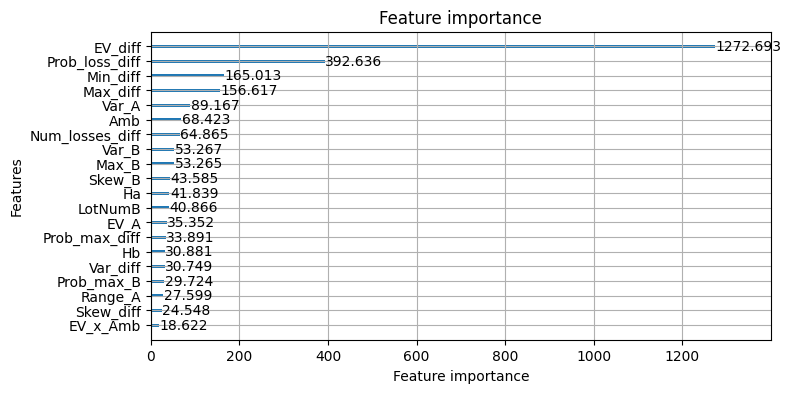

In [ ]:
_ = lgb.plot_importance(
        best_lgbm,
        max_num_features=20,
        importance_type='gain',
        figsize=(8, 4)
    )

CatBoost was also applied but it was the worst of the three so i cut it

### Method 3: Stacked Ensembles (StackingRegressor)

I also tried Voting Ensembles which while better than standalone boosting methods were still out performed by Stacked so i decided to showcase this one

After trying many different approaches i thought i would try a combinational approach with my top 2 best models by using the output of LightGBM and XGBoost to a linear model (Stacking Regressor)

In [ ]:
estimators = [('xgb', best_xgb), ('lgb', best_lgbm)]
final_estimator = Ridge()

sreg = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    n_jobs=-1
)

param_grid = {
    'final_estimator__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

sreg_grid = GridSearchCV(
    sreg,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=cv
)

sreg_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","StackingRegre...(), n_jobs=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'final_estimator__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

For the final estimator it tried : (Ridge, ElasticNet, LinearRegression, Lasso) and Ridge provided the best MAE

In [ ]:
best_sreg = sreg_grid.best_estimator_
print("Stacking Regressor best params:", sreg_grid.best_params_)

Stacking Regressor best params: {'final_estimator__alpha': 0.001}


In [ ]:
y_pred_sreg = best_sreg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_sreg)
r2 = r2_score(y_test, y_pred_sreg)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_sreg))

print(f"Test MAE: {mae}")
print(f"Test R²: {r2}")
print(f"Test RMSE: {rmse}")

Test MAE: 0.07364539486502841
Test R²: 0.8185244427001789
Test RMSE: 0.09425786574573296


In [ ]:
cv_results = cross_validate(
    best_sreg, X, y, cv=cv, scoring=scoring, return_train_score=True
)

train_mae = -np.mean(cv_results['train_neg_mean_absolute_error'])
val_mae = -np.mean(cv_results['test_neg_mean_absolute_error'])
val_mae_std = np.std(-cv_results['test_neg_mean_absolute_error'])

train_r2 = np.mean(cv_results['train_r2'])
val_r2 = np.mean(cv_results['test_r2'])
val_r2_std = np.std(cv_results['test_r2'])

train_rmse = -np.mean(cv_results['train_neg_root_mean_squared_error'])
val_rmse = -np.mean(cv_results['test_neg_root_mean_squared_error'])
val_rmse_std = np.std(-cv_results['test_neg_root_mean_squared_error'])

print("\n")
#print(f"Train MAE: {train_mae}")
print(f"Cross Validated Test MAE: {val_mae} ± {val_mae_std}")
#print(f"Train R²: {train_r2}")
print(f"Cross Validated Test R²: {val_r2} ± {val_r2_std}")
#print(f"Train RMSE: {train_rmse}")
print(f"Cross Validated Test RMSE: {val_rmse} ± {val_rmse_std}")



Cross Validated Test MAE: 0.07535720820318993 ± 0.0011985602991451182
Cross Validated Test R²: 0.8158588579834744 ± 0.004391183720921838
Cross Validated Test RMSE: 0.09514949034519445 ± 0.0007314835131082023


### Neural Network Method: TensorFlow Sequencial Model

For the Neural network method i TensorFlow, Specifically, based on tensorflow user guide since this is a simple regression issue I used a sequential model with 2 hiden neuron layer with activation="relu" and the output layer with activation="sigmoid" since i want Probability outputs

Sinced this dataset has a lot of varing values rather than StandardScaler() I scaled the features using tensorflow's normalization layer adapted to my training data

In [ ]:
normalizer = layers.Normalization()
normalizer.adapt(X_train.to_numpy())

To prevent Overfitting I added:

* A Dropout Layer

* L2 Regularization

* An Early Stop Callback monitoring validation loss

I used Optimizer Adam and set the loss metric to MAE since its my main concern

In [ ]:
def build_model(l2_strength=1e-4, dropout_rate=0.2, learning_rate=1e-3):

    model = models.Sequential([
        normalizer,
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dropout(float(dropout_rate)),
        layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizers.Adam(float(learning_rate)),
        loss="mae", #binary_crossentropy #mse #mae #these are other options, but MAE is our main focus
        metrics=["mae"]
    )

    return model

I tried many combinations of Layers and neuron numbers and it turns out the simple standard worked the best

In [ ]:
model = build_model()

# Train model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4534 - mae: 0.1468 - val_loss: 1.7784 - val_mae: 0.1065
Epoch 2/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8456 - mae: 0.1106 - val_loss: 1.5864 - val_mae: 0.0952
Epoch 3/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7229 - mae: 0.1034 - val_loss: 1.5241 - val_mae: 0.0916
Epoch 4/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6466 - mae: 0.0989 - val_loss: 1.5057 - val_mae: 0.0905
Epoch 5/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6056 - mae: 0.0966 - val_loss: 1.4646 - val_mae: 0.0880
Epoch 6/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5685 - mae: 0.0945 - val_loss: 1.4543 - val_mae: 0.0873
Epoch 7/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5501 - mae: 0.0934 - val_loss: 1.4446 - val_mae: 0.0868
Epoch 8/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5260 - mae: 0.0920 - val_loss: 1.4415 - val_mae: 0.0866
Epoch 9/200
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, sample_weight=w_test)
print("Weighted Test MAE:", test_mae)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3337 - mae: 0.0802  
Weighted Test MAE: 0.08023431897163391


In [ ]:
y_pred = model.predict(X_test).flatten()

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_list = []
rmse_list = []
r2_list = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{n_splits}")

    # Split data
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    w_train_fold, w_val_fold = sample_weight[train_idx], sample_weight[val_idx]

    # Build model
    model_cv = build_model()

    # Early stopping
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # Train model
    model_cv.fit(
        X_train_fold,
        y_train_fold,
        sample_weight=w_train_fold,
        validation_data=(X_val_fold, y_val_fold, w_val_fold),
        epochs=200,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    # Predictions
    y_pred_fold = model_cv.predict(X_val_fold).flatten()

    # Metrics (weighted)
    mae = np.average(np.abs(y_val_fold - y_pred_fold), weights=w_val_fold)
    rmse = np.sqrt(np.average((y_val_fold - y_pred_fold) ** 2, weights=w_val_fold))

    y_mean = np.average(y_val_fold, weights=w_val_fold)
    r2 = 1 - (
        np.sum(w_val_fold * (y_val_fold - y_pred_fold) ** 2) /
        np.sum(w_val_fold * (y_val_fold - y_mean) ** 2)
    )

    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)

    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}\n")

# ----- Average across folds -----
print("=== Cross-Validation Results ===")
print(f"Mean MAE: {np.mean(mae_list):.4f}")
print(f"Mean RMSE: {np.mean(rmse_list):.4f}")
print(f"Mean R²: {np.mean(r2_list):.4f}")

Fold 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 0.0763, RMSE: 0.0978, R²: 0.8013

Fold 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 0.0798, RMSE: 0.1013, R²: 0.7888

Fold 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 0.0788, RMSE: 0.1004, R²: 0.7969

Fold 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step
MAE: 0.0811, RMSE: 0.1020, R²: 0.7833

Fold 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MAE: 0.0795, RMSE: 0.1007, R²: 0.7833

=== Cross-Validation Results ===
Mean MAE: 0.0791
Mean RMSE: 0.1004
Mean R²: 0.7907


Good Results however Ensemble models outperformed it

In [ ]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_5 (Normalization) │ (None, 62)             │           125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,562 (72.52 KB)

 Trainable params: 6,145 (24.00 KB)

 Non-trainable params: 125 (504.00 B)

 Optimizer params: 12,292 (48.02 KB)

## Feature Importances of Best Performing Model (StackingRegressor)

> A stacked regressor is a two-level model composed of multiple base learners and a meta-learner. The final prediction is produced by the meta-model, which learns from the predictions of the base models, not directly from the original input features.

Αυτο σημαινει οτι απλα `.feature_importances_` δεν δουλευει και να δουλευε δε θα εδειχνε αυτο που μας βοηθαει να αξιολογησουμε την αξια των features



Για αυτο το λογο αποφασισα να δειξω το feature importance του Stacked Regressor χρησιμοποιωντας την μεθοδο: `permutation_importance()`



Με βαση το το scikit learn User guide:

> One key advantage of permutation feature importance is that it is model-agnostic, i.e. it can be applied to any fitted estimator.

tldr δεν επηρεαζεται απο το meta model και μας επιστρεφει το feature importance που οντως μας αφορα



Την λυση και το πως το `permutation_importance()` βοηθαει το βρηκα απο εδω: [https://scikit-learn.org/stable/modules/permutation_importance.html#] <br>
Βασισα τον κωδικα μου απο τα παδειγματα που βρηκα στο sklearn Documentation [Api](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html)

In [ ]:
result = permutation_importance(best_sreg, X, y, scoring='neg_mean_absolute_error', n_repeats=10, random_state=42)

In [ ]:
importances = result.importances_mean
indices = importances.argsort()[::-1]

print("Feature ranking:")
for i in indices:
    print(f"{X.columns[i]}: {importances[i]:.4f}")

Feature ranking:
EV_diff: 0.0882
Prob_loss_diff: 0.0210
Max_diff: 0.0201
Min_diff: 0.0143
Amb: 0.0099
Var_A: 0.0050
Var_B: 0.0049
LotNumB: 0.0045
Ha: 0.0039
EV_A: 0.0036
Hb: 0.0035
Skew_B: 0.0033
Num_losses_diff: 0.0032
Prob_max_diff: 0.0030
Prob_max_B: 0.0030
Skew_x_feedback: 0.0030
Max_B: 0.0028
La: 0.0026
Var_diff: 0.0024
Feedback: 0.0021
Lb: 0.0019
Skew_diff: 0.0016
EV_x_Amb: 0.0014
EV_B: 0.0013
Min_B: 0.0012
pHa: 0.0012
Skew_A: 0.0011
Range_B: 0.0010
n: 0.0010
Range_diff: 0.0010
Expected_loss_diff: 0.0009
Expected_loss_A: 0.0009
Range_A: 0.0009
Loss_gain_ratio_diff: 0.0009
Loss_gain_ratio_B: 0.0008
pHb: 0.0007
Expected_loss_B: 0.0007
Prob_loss_B: 0.0005
Loss_gain_ratio_A: 0.0005
Max_loss_diff: 0.0004
LotShapeB_2: 0.0003
Prob_loss_A: 0.0003
LotShapeB_3: 0.0002
Block_4: 0.0002
Block_2: 0.0001
Block_3: 0.0001
Block_5: 0.0001
Semi_var_B: 0.0001
LotShapeB_1: 0.0001
Prob_max_A: 0.0001
Has_loss_diff: 0.0001
Max_A: 0.0001
Corr: 0.0001
Min_A: 0.0001
Semi_var_diff: 0.0001
Semi_var_A: 0.0000

Μια διαφορα ομως ειναι οτι δειχνει τα αποτελσματα μας σε Boxplot: 

Features with zero importance: ['Has_loss_A', 'Has_loss_B', 'Num_losses_A', 'Max_loss_A']


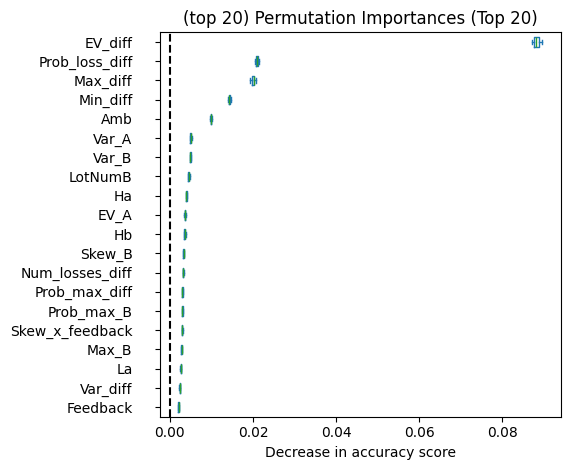

In [ ]:
# Identify features with zero importance
zero_features = X.columns[result.importances_mean == 0]
if len(zero_features) > 0:
    print("Features with zero importance:", list(zero_features))

non_zero_mask = result.importances_mean != 0

sorted_importances_idx = result.importances_mean[non_zero_mask].argsort()
top_k = 20
top_idx = np.argsort(result.importances_mean[non_zero_mask])[-top_k:]  # largest 12
importances = pd.DataFrame(
    result.importances[non_zero_mask][top_idx].T,
    columns=X.columns[non_zero_mask][top_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("(top 20) Permutation Importances (Top 20)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.tick_params(axis="y", pad=16)
ax.figure.tight_layout()
ax.figure.subplots_adjust(left=0.35)

Ας το μετατρεψουμε και σε bar graph

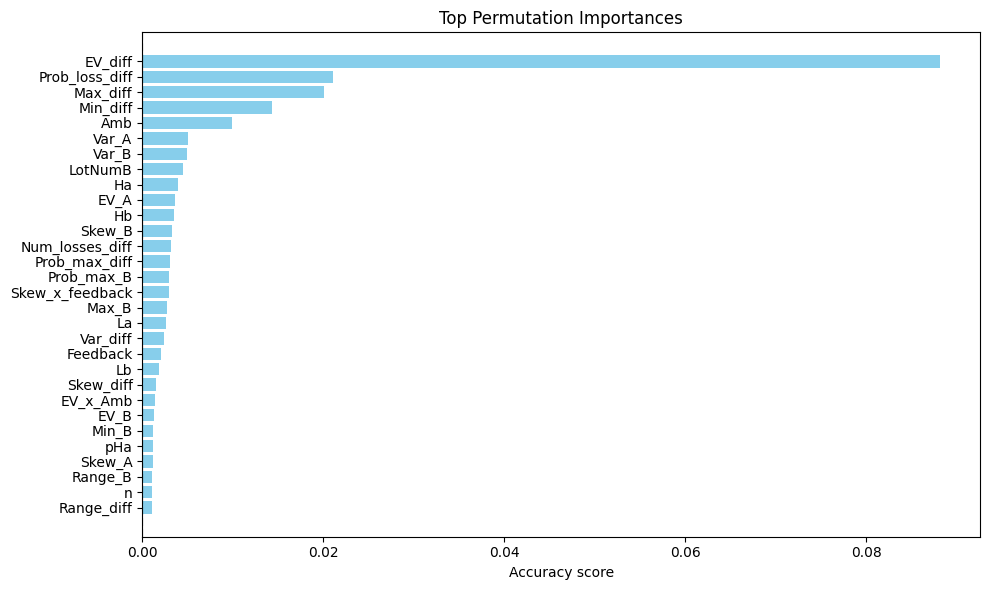

In [ ]:
# Filter zero-importance features
non_zero_mask = result.importances_mean != 0
importances_mean = result.importances_mean[non_zero_mask]
feature_names = X.columns[non_zero_mask]

# Select top 20 features by mean importance
top_k = 30
top_idx = np.argsort(importances_mean)[-top_k:]  # largest 20

top_features = feature_names[top_idx]
top_importances = importances_mean[top_idx]

# Plot as horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_features, top_importances, color="skyblue")
plt.axvline(x=0, color="k", linestyle="--")
plt.xlabel("Accuracy score")
plt.title("Top Permutation Importances")
plt.gca()
plt.tight_layout()
plt.show()

* Το πιο σημαντικο feature (as expected) ειναι η διαφορα των expected values `EV_DIFF`

* Αλλα σημαντικα features ειναι οι διαφορες μεταξυ των max και min payout και των πιθανοτητων για loss.

Υπαρχουν παρα πολλα features να εξηγησουμε αλλα φαινεται οτι ακολουθουν το τη intuitive λογικη οτι ο ανθρωπος επιλεγει gamble με βαση το ποσο κανει expect να κερδισει, το οτι φοβαται να χασει περισσοτερο αν κερδισει λιγοτερα.

## Best MAE

The best mae i got from a just Train Test splitted evaluation was: `0.07360359129264456`

Best Cross Validated MAE (numpy mean of 5 cv values):

0.07535720820318993